Using input file: /content/کامل.xlsx
Train shape: (66, 18, 12) (66, 2) Test shape: (23, 18, 12) (23, 2)
Epoch 1/300
5/5 - 5s - 940ms/step - loss: 0.1170 - val_loss: 0.0432 - learning_rate: 3.0000e-04
Epoch 2/300
5/5 - 1s - 148ms/step - loss: 0.0830 - val_loss: 0.0400 - learning_rate: 3.0000e-04
Epoch 3/300
5/5 - 1s - 122ms/step - loss: 0.0710 - val_loss: 0.0439 - learning_rate: 3.0000e-04
Epoch 4/300
5/5 - 0s - 83ms/step - loss: 0.0644 - val_loss: 0.0412 - learning_rate: 3.0000e-04
Epoch 5/300
5/5 - 1s - 121ms/step - loss: 0.0569 - val_loss: 0.0319 - learning_rate: 3.0000e-04
Epoch 6/300
5/5 - 0s - 79ms/step - loss: 0.0554 - val_loss: 0.0266 - learning_rate: 3.0000e-04
Epoch 7/300
5/5 - 1s - 124ms/step - loss: 0.0487 - val_loss: 0.0258 - learning_rate: 3.0000e-04
Epoch 8/300
5/5 - 1s - 154ms/step - loss: 0.0434 - val_loss: 0.0222 - learning_rate: 3.0000e-04
Epoch 9/300
5/5 - 1s - 157ms/step - loss: 0.0421 - val_loss: 0.0177 - learning_rate: 3.0000e-04
Epoch 10/300
5/5 - 1s - 142ms/step

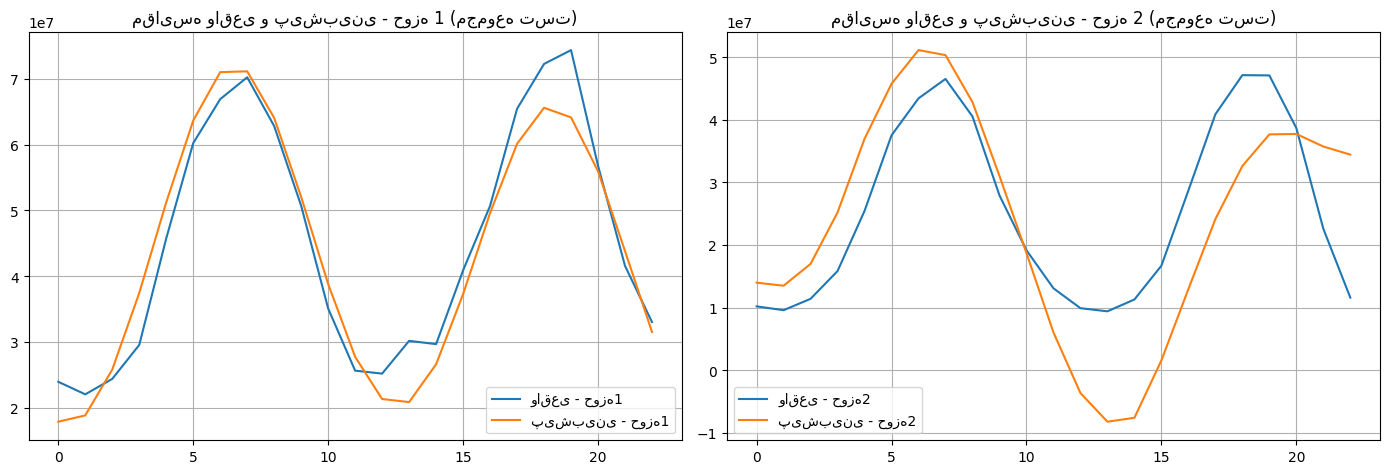

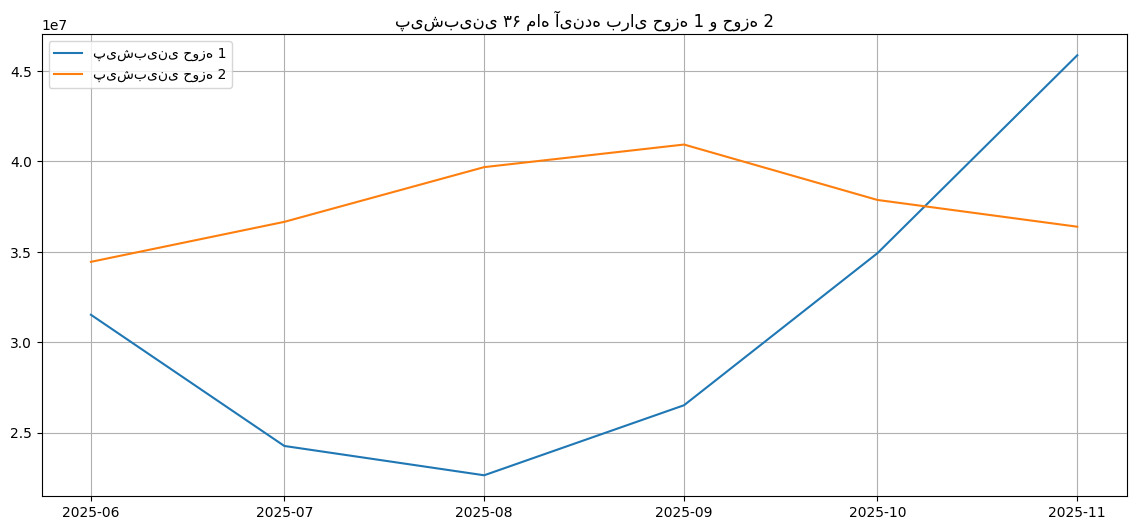

In [1]:
# -*- coding: utf-8 -*-
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)

input_path = r"/content/کامل.xlsx"
output_folder = r"D:\LSTM"
os.makedirs(output_folder, exist_ok=True)

def find_excel_file(base_path):
    if os.path.isfile(base_path):
        return base_path
    for ext in ['.xlsx', '.xls', '.xlsm']:
        candidate = base_path + ext
        if os.path.isfile(candidate):
            return candidate
    if os.path.isdir(base_path):
        files = glob.glob(os.path.join(base_path, "*.xlsx")) + glob.glob(os.path.join(base_path, "*.xls"))
        if len(files) > 0:
            return files[0]
    raise FileNotFoundError(f"فایل اکسل در مسیر '{base_path}' پیدا نشد. لطفاً مسیر/نام فایل را بررسی کنید.")

excel_file = find_excel_file(input_path)
print("Using input file:", excel_file)

df = pd.read_excel(excel_file)

def clean_weather_value(x):
    if pd.isnull(x):
        return np.nan
    s = str(x).strip()
    if s in ['-', '—', '', 'NA', 'N/A', 'nan']:
        return np.nan
    match = re.search(r'-?\d+(\.\d+)?', s.replace(',', ''))
    return float(match.group()) if match else np.nan

weather_features = ['High Temp', 'Low Temp', 'Avg Temp', 'Rainfall']
target_1 = 'حوزه 1'
target_2 = 'حوزه2'
date_col_candidates = ['تاریخ', 'Date', 'date', 'datetime']

date_col = None
for c in date_col_candidates:
    if c in df.columns:
        date_col = c
        break
if date_col is None:
    raise KeyError("ستون تاریخ پیدا نشد. لطفا ستون تاریخ را با نام 'تاریخ' در فایل قرار دهید.")

for col in weather_features:
    if col in df.columns:
        df[col] = df[col].apply(clean_weather_value)
    else:
        raise KeyError(f"ستون ویژگی '{col}' در داده پیدا نشد. لطفا نام ستونها را بررسی کنید.")

for t in [target_1, target_2]:
    if t not in df.columns:
        raise KeyError(f"ستون هدف '{t}' پیدا نشد. نام ستون‌ها را بررسی کنید.")

df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=[date_col])
df = df.sort_values(by=date_col).reset_index(drop=True)
df.set_index(date_col, inplace=True)

if 'ماه' not in df.columns:
    df['ماه'] = df.index.month
if 'سال' not in df.columns:
    df['سال'] = df.index.year

df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

# **افزودن ویژگی lag برای حوزه‌ها (مصرف ماه‌های قبلی)**
lag_months = [1,2,3]
for lag in lag_months:
    df[f'{target_1}_lag{lag}'] = df[target_1].shift(lag)
    df[f'{target_2}_lag{lag}'] = df[target_2].shift(lag)

# حذف ردیف‌هایی که NaN دارند به خاطر lag ها
features = weather_features + ['month_sin', 'month_cos']
lag_features = [f'{target_1}_lag{lag}' for lag in lag_months] + [f'{target_2}_lag{lag}' for lag in lag_months]
all_features = features + lag_features

df = df.dropna(subset=all_features + [target_1, target_2]).copy()

sequence_length = 18
if len(df) <= sequence_length:
    raise ValueError(f"تعداد ردیف‌های مفید ({len(df)}) کمتر یا مساوی طول دنباله ({sequence_length}) است.")

monthly_climatology = df[weather_features].groupby(df.index.month).mean()
for col in weather_features:
    monthly_climatology[col] = monthly_climatology[col].fillna(df[col].mean())

X_all = df[all_features].values
y_all = df[[target_1, target_2]].values

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled_all = scaler_X.fit_transform(X_all)
y_scaled_all = scaler_y.fit_transform(y_all)

def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled_all, y_scaled_all, sequence_length)

split_index = int(len(X_seq) * 0.75)
X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

print("Train shape:", X_train.shape, y_train.shape, "Test shape:", X_test.shape, y_test.shape)

def build_lstm_multioutput(input_shape, units=256, lr=3e-4):
    inputs = Input(shape=input_shape)
    x = LSTM(units, return_sequences=True)(inputs)
    x = Dropout(0.2)(x)
    x = LSTM(units//2)(x)
    x = Dropout(0.2)(x)
    outputs = Dense(2)(x)  # دو خروجی حوزه‌ها
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

model = build_lstm_multioutput((sequence_length, X_train.shape[2]), units=256, lr=3e-4)

es = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)
rlrop = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)

epochs = 300
batch_size = 16

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs, batch_size=batch_size,
    callbacks=[es, rlrop],
    shuffle=False,
    verbose=2
)

# ارزیابی

def evaluate_and_print_multioutput(model, X_test, y_test_scaled, scaler_y):
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(y_test_scaled)
    results = []
    for i, area in enumerate(['حوزه 1', 'حوزه 2']):
        mae = mean_absolute_error(y_true[:,i], y_pred[:,i])
        rmse = np.sqrt(mean_squared_error(y_true[:,i], y_pred[:,i]))
        try:
            r2 = r2_score(y_true[:,i], y_pred[:,i])
        except:
            r2 = np.nan
        print(f"--- Evaluation {area} ---")
        print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")
        results.append((mae, rmse, r2))
    return y_true, y_pred, results

y_true, y_pred, eval_results = evaluate_and_print_multioutput(model, X_test, y_test, scaler_y)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(y_true[:,0], label='واقعی - حوزه1')
plt.plot(y_pred[:,0], label='پیش‌بینی - حوزه1')
plt.title("مقایسه واقعی و پیش‌بینی - حوزه 1 (مجموعه تست)")
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(y_true[:,1], label='واقعی - حوزه2')
plt.plot(y_pred[:,1], label='پیش‌بینی - حوزه2')
plt.title("مقایسه واقعی و پیش‌بینی - حوزه 2 (مجموعه تست)")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

# بهبود تابع پیش‌بینی چندماهه با استفاده از lagهای پیش‌بینی شده برای حوزه‌ها
def make_future_feature_vector_from_climatology_and_preds(last_date, step_ahead_months, prev_preds_area1, prev_preds_area2):
    target_month = ((last_date.month - 1 + step_ahead_months) % 12) + 1
    weather_vec = monthly_climatology.loc[target_month, weather_features].values
    month_sin = np.sin(2 * np.pi * target_month / 12)
    month_cos = np.cos(2 * np.pi * target_month / 12)

    # برای lag ها مقدارها را از پیش‌بینی‌های قبلی یا آخرین مقادیر واقعی می‌گیریم:
    # lag1 = مقدار ماه قبل (step_ahead_months-1)
    # lag2 = مقدار دو ماه قبل (step_ahead_months-2)
    # lag3 = مقدار سه ماه قبل (step_ahead_months-3)
    def get_lag_value(lag):
        idx = step_ahead_months - lag - 1
        if idx >= 0:
            return prev_preds_area1[idx], prev_preds_area2[idx]
        else:
            # اگر lag بیشتر از تعداد پیش‌بینی‌ها بود، مقدار 0 یا مقدار آخر واقعی را برگردان
            return prev_preds_area1[0], prev_preds_area2[0]

    lag1_a1, lag1_a2 = get_lag_value(1)
    lag2_a1, lag2_a2 = get_lag_value(2)
    lag3_a1, lag3_a2 = get_lag_value(3)

    return np.array(list(weather_vec) + [month_sin, month_cos, lag1_a1, lag2_a1, lag3_a1, lag1_a2, lag2_a2, lag3_a2])

def multi_step_forecast_multioutput(model, scaler_X, scaler_y, last_sequence_scaled, last_date, steps):
    preds_scaled = []
    input_seq = last_sequence_scaled.copy()
    preds_area1 = []
    preds_area2 = []
    for step in range(1, steps+1):
        pred_scaled = model.predict(input_seq.reshape(1, *input_seq.shape), verbose=0)[0]
        preds_scaled.append(pred_scaled)
        pred_inv = scaler_y.inverse_transform(pred_scaled.reshape(1,-1)).flatten()
        preds_area1.append(pred_inv[0])
        preds_area2.append(pred_inv[1])

        future_feat = make_future_feature_vector_from_climatology_and_preds(last_date, step, preds_area1, preds_area2)
        future_feat_scaled = scaler_X.transform(future_feat.reshape(1,-1)).reshape(-1)

        input_seq = np.vstack([input_seq[1:], future_feat_scaled])
    preds_scaled = np.array(preds_scaled)
    preds = scaler_y.inverse_transform(preds_scaled)
    preds[:,0] = np.maximum(preds[:,0], 0)
    preds[:,1] = np.maximum(preds[:,1], 0)
    return preds

last_seq = X_seq[-1]
last_date = df.index[-1]

future_steps = 6
future_preds = multi_step_forecast_multioutput(model, scaler_X, scaler_y, last_seq, last_date, future_steps)

months = pd.date_range(start=last_date + pd.offsets.MonthBegin(), periods=future_steps, freq='MS')

plt.figure(figsize=(14,6))
plt.plot(months, future_preds[:,0], label='پیش‌بینی حوزه 1')
plt.plot(months, future_preds[:,1], label='پیش‌بینی حوزه 2')
plt.title("پیش‌بینی ۳۶ ماه آینده برای حوزه 1 و حوزه 2")
plt.legend()
plt.grid(True)
plt.show()

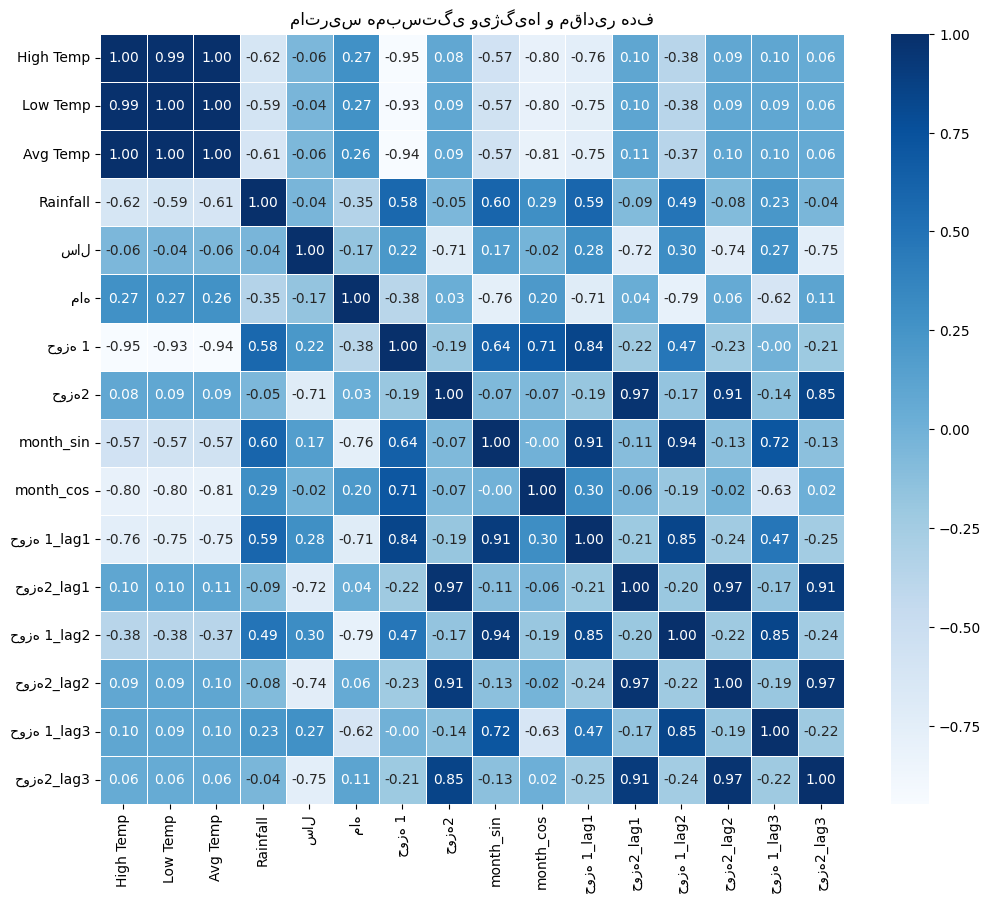

In [2]:
import seaborn as sns
import numpy as np

# محاسبه ماتریس همبستگی فقط برای ستون‌های عددی
df_numeric = df.select_dtypes(include=np.number)
correlation_matrix = df_numeric.corr()

plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='Blues', linewidths=0.5)
plt.title("ماتریس همبستگی ویژگی‌ها و مقادیر هدف")
plt.show()


--- نتایج حوزه: حوزه 1 ---
MAE: 3855615.8145
RMSE: 4678150.1666
R2: 0.9283


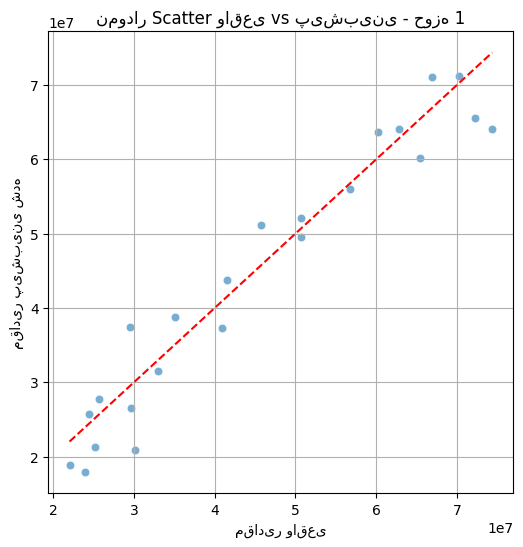

Correlation بین واقعی و پیش‌بینی برای حوزه 1: 0.9661


--- نتایج حوزه: حوزه 2 ---
MAE: 9790318.0025
RMSE: 11584352.4269
R2: 0.3055


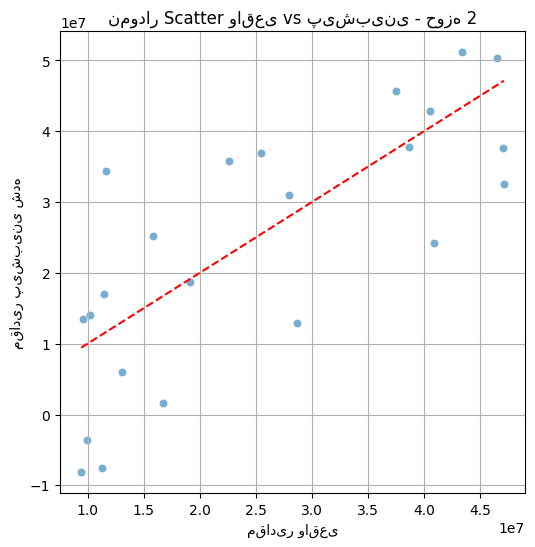

Correlation بین واقعی و پیش‌بینی برای حوزه 2: 0.7610




In [3]:
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# y_true و y_pred از کد قبلی داریم (ارزیابی مجموعه تست)
# برای حوزه 1
area_names = ['حوزه 1', 'حوزه 2']

for i, area in enumerate(area_names):
    print(f"--- نتایج حوزه: {area} ---")
    y_t = y_true[:, i]
    y_p = y_pred[:, i]

    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2 = r2_score(y_t, y_p)

    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")

    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_t, y=y_p, alpha=0.6)
    plt.plot([min(y_t), max(y_t)], [min(y_t), max(y_t)], 'r--')
    plt.xlabel('مقادیر واقعی')
    plt.ylabel('مقادیر پیش‌بینی شده')
    plt.title(f"نمودار Scatter واقعی vs پیش‌بینی - {area}")
    plt.grid(True)
    plt.show()

    corr = np.corrcoef(y_t, y_p)[0,1]
    print(f"Correlation بین واقعی و پیش‌بینی برای {area}: {corr:.4f}")
    print("\n")